# Prediksi Harga Emas Menggunakan Machine Learning
Dataset asli: gold_price.csv

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Semua library berhasil diimport")


TensorFlow Version: 2.10.0
Semua library berhasil diimport


In [4]:
!pip install tensorflow


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:

# Membaca dataset asli
df = pd.read_csv('../dataset/gold_price.csv')

df.head()


,Date,Price,Open,High,Low,Vol.,Change %
0,05/08/2026,"4,751.31","4,713.36","4,754.16","4,702.89",59.30K,0.86%
1,05/07/2026,"4,710.90","4,702.20","4,775.20","4,693.30",159.53K,0.35%
2,05/06/2026,"4,694.30","4,569.30","4,734.60","4,556.10",160.44K,2.75%
3,05/05/2026,"4,568.50","4,534.00","4,597.50","4,522.70",88.28K,0.78%
4,05/04/2026,"4,533.30","4,644.00","4,650.60","4,510.10",117.01K,-2.39%


In [6]:
# Membersihkan data

df['Price'] = df['Price'].astype(str).str.replace(',', '')
df['Open'] = df['Open'].astype(str).str.replace(',', '')
df['High'] = df['High'].astype(str).str.replace(',', '')
df['Low'] = df['Low'].astype(str).str.replace(',', '')

# Konversi ke float
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')

# Membersihkan volume
df['Vol.'] = df['Vol.'].astype(str).str.replace('K', '')
df['Vol.'] = pd.to_numeric(df['Vol.'], errors='coerce') * 1000

# Membersihkan Change %
df['Change %'] = df['Change %'].astype(str).str.replace('%', '')
df['Change %'] = pd.to_numeric(df['Change %'], errors='coerce')

# Konversi tanggal
df['Date'] = pd.to_datetime(df['Date'])

# Hapus data kosong
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Jumlah data setelah dibersihkan:", len(df))

df.head()

Jumlah data setelah dibersihkan: 3781


,Date,Price,Open,High,Low,Vol.,Change %
0,2026-05-08,4751.31,4713.36,4754.16,4702.89,59300.0,0.86
1,2026-05-07,4710.90,4702.20,4775.20,4693.30,159530.0,0.35
2,2026-05-06,4694.30,4569.30,4734.60,4556.10,160440.0,2.75
3,2026-05-05,4568.50,4534.00,4597.50,4522.70,88280.0,0.78
4,2026-05-04,4533.30,4644.00,4650.60,4510.10,117010.0,-2.39


In [7]:

# Feature dan target

X = df[['Open', 'High', 'Low', 'Vol.']]
y = df['Price']

# Normalisasi
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_scaled,
    test_size=0.2,
    random_state=42
)

print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))


Jumlah data train: 3024
Jumlah data test: 757


## 1. Linear Regression

In [8]:

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression")
print("MSE :", mean_squared_error(y_test, lr_pred))
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("R2  :", r2_score(y_test, lr_pred))


Linear Regression
MSE : 5.414573524884554e-06
MAE : 0.0012241229555159153
R2  : 0.9998297133519587


## 2. Artificial Neural Network (ANN)

In [9]:
# ==========================================
# Pelatihan Model ANN
# ==========================================
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Melatih model ANN...")
history_ann = ann_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

ann_pred = ann_model.predict(X_test)

print("\n--- Hasil Evaluasi ANN ---")
print("MSE :", mean_squared_error(y_test, ann_pred))
print("MAE :", mean_absolute_error(y_test, ann_pred))
print("R2  :", r2_score(y_test, ann_pred))

# ==========================================
# INI YANG PALING PENTING: Menyimpan Model
# ==========================================
ann_model.save('../models/model_ann.h5')
print("\nModel ANN selesai dilatih dan file 'model_ann.h5' berhasil disimpan!")

Melatih model ANN...
Epoch 1/30
86/86 [==============================] - 5s 20ms/step - loss: 0.0021 - mae: 0.0211 - val_loss: 4.4312e-05 - val_mae: 0.0045
Epoch 2/30
86/86 [==============================] - 1s 11ms/step - loss: 2.3363e-05 - mae: 0.0031 - val_loss: 2.0100e-05 - val_mae: 0.0027
Epoch 3/30
86/86 [==============================] - 1s 6ms/step - loss: 1.4660e-05 - mae: 0.0023 - val_loss: 1.3831e-05 - val_mae: 0.0023
Epoch 4/30
86/86 [==============================] - 0s 5ms/step - loss: 1.1401e-05 - mae: 0.0021 - val_loss: 1.2259e-05 - val_mae: 0.0020
Epoch 5/30
86/86 [==============================] - 1s 9ms/step - loss: 1.0444e-05 - mae: 0.0020 - val_loss: 3.3748e-05 - val_mae: 0.0043
Epoch 6/30
86/86 [==============================] - 1s 10ms/step - loss: 3.1218e-05 - mae: 0.0037 - val_loss: 1.2254e-05 - val_mae: 0.0021
Epoch 7/30
86/86 [==============================] - 1s 6ms/step - loss: 8.9690e-06 - mae: 0.0019 - val_loss: 1.0671e-05 - val_mae: 0.0020
Epoch 8/30
86/

## 3. Recurrent Neural Network (RNN / LSTM)

In [10]:
# Reshape data untuk LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(1, X_train.shape[1])),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

print("Melatih model LSTM...")
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

lstm_pred = lstm_model.predict(X_test_lstm)

print("\n--- Hasil Evaluasi LSTM ---")
print("MSE :", mean_squared_error(y_test, lstm_pred))
print("MAE :", mean_absolute_error(y_test, lstm_pred))
print("R2  :", r2_score(y_test, lstm_pred))

# ==========================================
# INI YANG PALING PENTING: Menyimpan Model
# ==========================================
lstm_model.save('../models/model_lstm.h5')
print("\nModel LSTM selesai dilatih dan file 'model_lstm.h5' berhasil disimpan!")

Melatih model LSTM...
Epoch 1/30
86/86 [==============================] - 3s 9ms/step - loss: 0.0307 - val_loss: 0.0116
Epoch 2/30
86/86 [==============================] - 0s 4ms/step - loss: 0.0078 - val_loss: 0.0017
Epoch 3/30
86/86 [==============================] - 0s 5ms/step - loss: 6.5658e-04 - val_loss: 2.0767e-04
Epoch 4/30
86/86 [==============================] - 0s 5ms/step - loss: 2.1013e-04 - val_loss: 1.1628e-04
Epoch 5/30
86/86 [==============================] - 0s 5ms/step - loss: 1.3753e-04 - val_loss: 6.7647e-05
Epoch 6/30
86/86 [==============================] - 1s 6ms/step - loss: 1.0182e-04 - val_loss: 4.9322e-05
Epoch 7/30
86/86 [==============================] - 1s 6ms/step - loss: 7.8141e-05 - val_loss: 3.6938e-05
Epoch 8/30
86/86 [==============================] - 1s 6ms/step - loss: 6.3559e-05 - val_loss: 3.1666e-05
Epoch 9/30
86/86 [==============================] - 1s 7ms/step - loss: 5.5154e-05 - val_loss: 3.0216e-05
Epoch 10/30
86/86 [=====================

## 4. K-Means Clustering

In [11]:
# K-Means Clustering
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)

# Memasukkan data ke dalam model
clusters = kmeans_model.fit_predict(X_scaled)

# Menambahkan hasil prediksi cluster ke dalam DataFrame
df['Cluster'] = clusters

# Menampilkan hasilnya (Ganti 'Close' menjadi 'Price' agar sesuai dengan datamu)
print(df[['Date', 'Price', 'Cluster']].head())

# Menyimpan Model
import joblib
joblib.dump(kmeans_model, '../models/model_kmeans.pkl')
print("\nK-Means clustering selesai dan file 'model_kmeans.pkl' berhasil disimpan!")

        Date    Price  Cluster
0 2026-05-08  4751.31        1
1 2026-05-07  4710.90        1
2 2026-05-06  4694.30        1
3 2026-05-05  4568.50        1
4 2026-05-04  4533.30        1

K-Means clustering selesai dan file 'model_kmeans.pkl' berhasil disimpan!


FileNotFoundError: [Errno 2] No such file or directory: 'static/plots/kmeans_cluster.png'

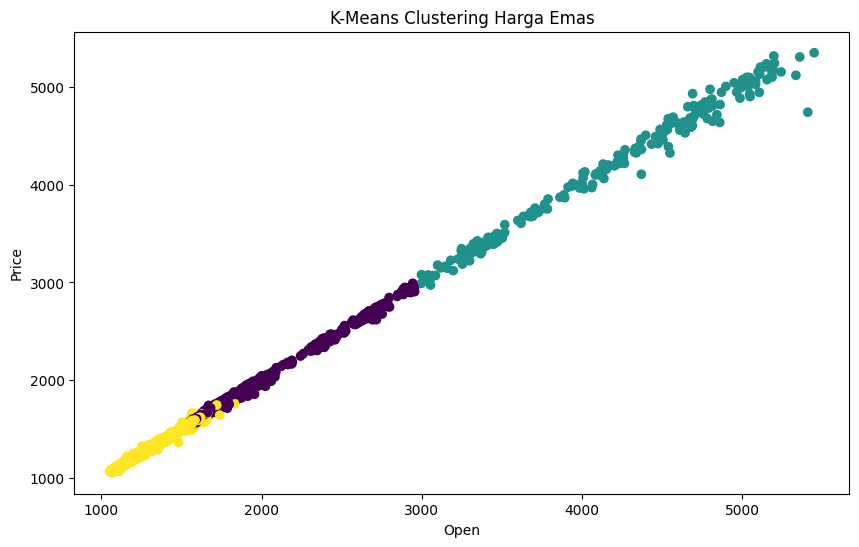

In [ ]:
# Tambahkan baris ini untuk memanggil pustaka pembuat grafik
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['Open'],
    df['Price'],
    c=df['Cluster'],
    cmap='viridis' # Tambahan kecil agar warnanya lebih kontras dan cantik
)

plt.title('K-Means Clustering Harga Emas')
plt.xlabel('Open')
plt.ylabel('Price')

# --- INI BAGIAN YANG DIPERBARUI ---
# Menambahkan ../ agar Python mundur satu folder sebelum masuk ke static/plots
plt.savefig('../static/plots/kmeans_cluster.png', bbox_inches='tight')

plt.show()

## 5. Backpropagation Model (MLP)

In [ ]:

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation='relu',
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train, y_train.ravel())

mlp_pred = mlp_model.predict(X_test)

print("Backpropagation / MLP")
print("MSE :", mean_squared_error(y_test, mlp_pred))
print("MAE :", mean_absolute_error(y_test, mlp_pred))
print("R2  :", r2_score(y_test, mlp_pred))


## Visualisasi Prediksi

In [ ]:

y_test_asli = scaler_y.inverse_transform(y_test)

lr_pred_asli = scaler_y.inverse_transform(lr_pred)
ann_pred_asli = scaler_y.inverse_transform(ann_pred)
lstm_pred_asli = scaler_y.inverse_transform(lstm_pred)
mlp_pred_asli = scaler_y.inverse_transform(mlp_pred.reshape(-1,1))

plt.figure(figsize=(14,7))

plt.plot(y_test_asli[:100], label='Harga Asli')
plt.plot(lr_pred_asli[:100], label='LR')
plt.plot(ann_pred_asli[:100], label='ANN')
plt.plot(lstm_pred_asli[:100], label='LSTM')
plt.plot(mlp_pred_asli[:100], label='MLP')

plt.title('Perbandingan Prediksi Model')
plt.xlabel('Data')
plt.ylabel('Harga Emas')
plt.legend()

plt.show()


In [ ]:
# Membuat Plot Evaluasi dan Menyimpan Gambar

import matplotlib.pyplot as plt
import os

# Pastikan foldernya ada
os.makedirs('../static/plots', exist_ok=True)

# 1. Plot Training Loss Curve (ANN vs LSTM)
plt.figure(figsize=(10, 5))
plt.plot(history_ann.history['loss'], label='ANN Train Loss', color='blue')
plt.plot(history_ann.history['val_loss'], label='ANN Validation Loss', color='cyan', linestyle='--')
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss', color='red')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss', color='orange', linestyle='--')
plt.title('Kurva Loss Training: ANN vs LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('../static/plots/loss_curve.png') # MENYIMPAN GAMBAR 1
plt.close()

# 2. Plot Perbandingan Harga Asli vs Prediksi (100 Hari Terakhir)
y_test_asli = scaler_y.inverse_transform(y_test)
ann_pred_asli = scaler_y.inverse_transform(ann_pred.reshape(-1, 1))
lstm_pred_asli = scaler_y.inverse_transform(lstm_pred.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(y_test_asli[-100:], label='Harga Asli', color='black', linewidth=2.5)
plt.plot(ann_pred_asli[-100:], label='Prediksi ANN', linestyle='-.', color='blue')
plt.plot(lstm_pred_asli[-100:], label='Prediksi LSTM', linestyle=':', color='red')
plt.title('Perbandingan Harga Asli vs Prediksi Model (100 Hari Terakhir)')
plt.xlabel('Waktu (Data Test)')
plt.ylabel('Harga (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../static/plots/comparison.png') # MENYIMPAN GAMBAR 2
plt.close()

print("Berhasil! Kedua gambar grafik sudah dicetak dan disimpan ke folder static/plots/")

In [ ]:
# Plot Residual (Sisa Error dari Prediksi ANN)
residuals_ann = y_test_asli - ann_pred_asli

plt.figure(figsize=(8, 5))
plt.scatter(ann_pred_asli, residuals_ann, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title('Residual Plot (Distribusi Error Model ANN)')
plt.xlabel('Nilai Prediksi Harga (USD)')
plt.ylabel('Error / Selisih (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../static/plots/residual_plot.png') # MENYIMPAN GAMBAR 3
plt.close()

print("Gambar Residual Plot berhasil dibuat!")